In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=True)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds_ctrl = scarf.DataStore(f"{ctrl_path}/data.zarr", nthreads=4)
ds_stim = scarf.DataStore(f"{stim_path}/data.zarr", nthreads=4)

Downloading bucket files: 56411732 / 56411732 complete

Downloading bytes: 56411732 / 56411732 complete

Downloading bucket files: 57052189 / 57052189 complete

Downloading bytes: 57052189 / 57052189 complete

In [2]:
ds_ctrl.cells.insert(
    "reference_batch",
    np.repeat("control", ds_ctrl.cells.N),
    overwrite=True,
)

In [3]:
reference = ds_ctrl.build_mapping_reference(
    feat_key="hvgs",
    batch_columns=["reference_batch"],
)
reference

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading uncorrected latent dimensions: 1 / 1 complete

Harmonizing batches: 50 / 50 complete

Fitting ANN: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

MappingReference(datastore=DataStore has 14526 (14619) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nFeatures', 'RNA_clusters', 
            'RNA_leiden_cluster', 'RNA_UMAP2', 'cluster_labels', 'RNA_UMAP1', 'RNA_nCounts', 
            'RNA_percentMito', 'RNA_percentRibo', 'reference_batch'
   RNA assay has 11377 (35635) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'I__hvgs', 
            'nCells', assay_name='RNA', cell_key='I', feature_key='hvgs', reduction_path='RNA/artifacts/reduction/1418f74db6ab0398a0dffd1dab0f31f39cc081abad002bd17a466877f9c791ec', ann_path='RNA/artifacts/ann_index/6fafb52c200c8a1520d10c0e14ac63063dea30e6dff6df203f32bd8ac7be3d75', artifact_path='RNA/artifacts/mapping_reference/aa4507d427c59f021b52fb8fda2acc41412d50ca2ac5dbac25d6964348c7c1c9', model=SymphonyReferenceModel(feature_means=array([0.00745194, 0.00239813, 0.02343847, ..., 0.01111884, 0.01877808,
       0.02064941], shape=(2000,)), featu

In [4]:
reference = ds_ctrl.get_mapping_reference(feat_key="hvgs")

In [5]:
query_batches = pd.DataFrame(
    {
        "reference_batch": np.repeat(
            "stimulated",
            len(ds_stim.cells.fetch("ids", key="I")),
        )
    }
)
reference.map_query(
    target_assay=ds_stim.RNA,
    target_name="stim_atlas",
    target_feat_key="hvgs_stim_atlas",
    save_k=5,
    query_batches=query_batches,
)

Normalizing with feature subset: 4 / 4 complete

(RNA) Writing aligned data to normed__I__hvgs_stim_atlas: 4 / 4 complete

Mapping cells from stim_atlas with Symphony-style correction: 1 / 1 complete

MappingResult(n_cells=14345, correction_method='symphony', diagnostics={'featureCoverage': 1.0, 'queryBatchCount': 1.0, 'zeroNormCellCount': 0.0, 'algorithmVariant': 'symphony'}, arrays=not loaded, projection_path='RNA/artifacts/projection/650103fc9042584...')

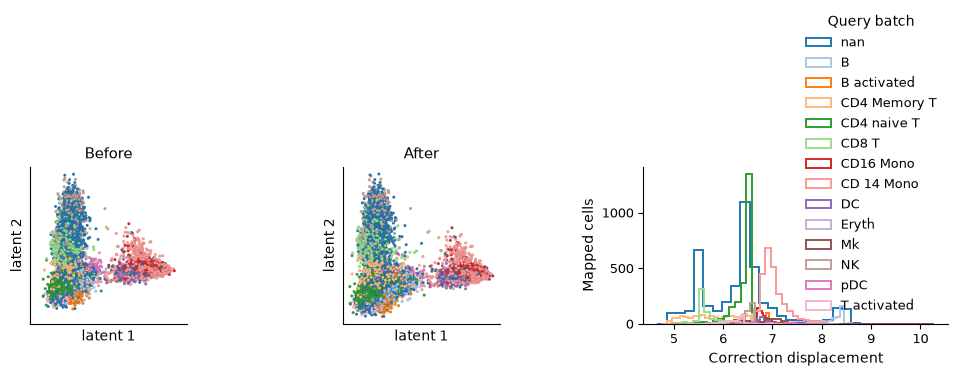

In [6]:
ds_ctrl.plots.mapping_correction(
    target_name="stim_atlas",
    batch_labels=ds_stim.cells.fetch("cluster_labels"),
)

In [7]:
mapped = ds_ctrl.get_mapping_result(
    "stim_atlas",
    load_arrays=True,
)
mapped.diagnostics

{'featureCoverage': 1.0,
 'queryBatchCount': 1.0,
 'algorithmVariant': 'symphony'}

In [8]:
reference.map_query(
    target_assay=ds_ctrl.RNA,
    target_name="control_self_map",
    target_feat_key="hvgs_control_self_map",
    save_k=5,
    query_batches=pd.DataFrame(
        {
            "reference_batch": ds_ctrl.cells.fetch(
                "reference_batch",
                key="I",
            )
        }
    ),
)
self_mapped = ds_ctrl.get_mapping_result(
    "control_self_map",
    load_arrays=True,
)
float(
    np.linalg.norm(
        self_mapped.corrected_latent
        - self_mapped.uncorrected_latent,
        axis=1,
    ).max()
)

Normalizing with feature subset: 4 / 4 complete

(RNA) Writing aligned data to normed__I__hvgs_control_self_map: 4 / 4 complete

Mapping cells from control_self_map with Symphony-style correction: 1 / 1 complete

0.01724216926413855

In [9]:
transferred = ds_ctrl.get_target_classes(
    target_name="stim_atlas",
    reference_class_group="cluster_labels",
    threshold_fraction=0.6,
)
ds_stim.cells.insert(
    "atlas_labels",
    transferred.to_numpy(),
    overwrite=True,
)

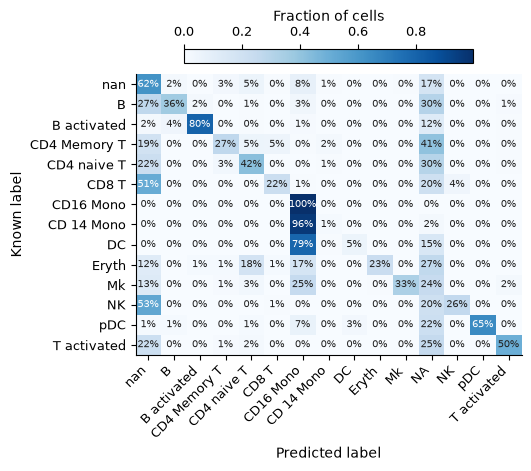

In [10]:
ds_ctrl.plots.mapping_confusion(
    target_name="stim_atlas",
    reference_class_group="cluster_labels",
    known_labels=ds_stim.cells.fetch("cluster_labels"),
    normalize="true",
    threshold_fraction=0.6,
)

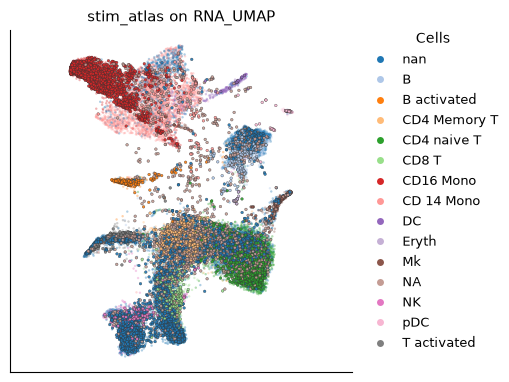

In [11]:
ds_ctrl.plots.mapping_projection(
    target_name="stim_atlas",
    reference_layout_key="RNA_UMAP",
    reference_groups="cluster_labels",
    target_groups=transferred.to_numpy(),
    ref_name="control atlas",
)